In [1]:
# Librerías a importar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# Lectura del dataset en formato CSV 
df = pd.read_csv('../Trabajo Fin de Master/diabetes_dataset_clean.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295971 entries, 0 to 295970
Data columns (total 22 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   GENHLTH   295971 non-null  float64
 1   SEXVAR    295971 non-null  float64
 2   _RACE     295971 non-null  float64
 3   _AGE_G    295971 non-null  float64
 4   _INCOMG1  295971 non-null  float64
 5   EMPLOY1   295971 non-null  float64
 6   _EDUCAG   295971 non-null  float64
 7   _RFHYPE6  295971 non-null  float64
 8   _RFCHOL3  295971 non-null  float64
 9   DIFFWALK  295971 non-null  float64
 10  BLIND     295971 non-null  float64
 11  _SMOKER3  295971 non-null  float64
 12  _RFDRHV8  295971 non-null  float64
 13  _BMI5     295971 non-null  float64
 14  MENTHLTH  295971 non-null  float64
 15  PHYSHLTH  295971 non-null  float64
 16  CVDCRHD4  295971 non-null  float64
 17  EXERANY2  295971 non-null  float64
 18  _HLTHPL1  295971 non-null  float64
 19  DECIDE    295971 non-null  float64
 20  CHCK

In [3]:
# Forma del dataset a analizar (filas, columnas)
df.shape

(295971, 22)

In [4]:
# Cambio de nombre de las columnas del dataset
df = df.rename(columns={'GENHLTH':'salud_gral', 'SEXVAR':'sexo', '_RACE':'raza_etnicidad', '_AGE_G':'edad', 
                        '_INCOMG1':'ingreso_anual', 'EMPLOY1':'empleado', '_EDUCAG':'nvl_educacion', 
                        '_RFHYPE6':'presion_alta', '_RFCHOL3':'colesterol_alto', 'DIFFWALK':'dif_caminar', 
                        'BLIND':'ciego_o_dif_ver', '_SMOKER3':'fumador', '_RFDRHV8':'alcoholismo', 
                        '_BMI5':'indice_masa_corporal', 'MENTHLTH':'salud_mental', 'PHYSHLTH':'salud_fisica', 
                        'CVDCRHD4':'enf_coronaria','EXERANY2':'act_fisica', '_HLTHPL1':'seguro_gastos_medicos', 
                        'DECIDE':'dif_concentrarse', 'CHCKDNY2':'enf_riñones', 'DIABETE4':'diabetes'})

In [87]:
df.isnull().sum()
df['sexo'].value_counts()

2.0    155967
1.0    140004
Name: sexo, dtype: int64

In [6]:
# Descripción general de las columnas con varables numéricas
df.describe()

,salud_gral,sexo,raza_etnicidad,edad,ingreso_anual,empleado,nvl_educacion,presion_alta,colesterol_alto,dif_caminar,...,alcoholismo,indice_masa_corporal,salud_mental,salud_fisica,enf_coronaria,act_fisica,seguro_gastos_medicos,dif_concentrarse,enf_riñones,diabetes
count,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000,...,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000,295971.000000
mean,2.578070,1.526967,1.981505,4.611945,5.221664,3.885800,3.163205,1.432944,1.424315,1.844603,...,1.060330,28.702694,57.943738,57.687638,1.940254,1.226542,1.036865,1.894493,1.950002,2.725470
std,1.030489,0.499273,2.180971,1.493020,2.058214,2.875758,0.913494,0.495484,0.494239,0.362283,...,0.238098,6.492192,38.249654,38.162266,0.237016,0.418595,0.188431,0.307206,0.217941,0.736837
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,12.020000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,4.000000,4.000000,1.000000,2.000000,1.000000,1.000000,2.000000,...,1.000000,24.330000,10.000000,10.000000,2.000000,1.000000,1.000000,2.000000,2.000000,3.000000
50%,3.000000,2.000000,1.000000,5.000000,5.000000,2.000000,3.000000,1.000000,1.000000,2.000000,...,1.000000,27.460000,88.000000,88.000000,2.000000,1.000000,1.000000,2.000000,2.000000,3.000000
75%,3.000000,2.000000,1.000000,6.000000,6.000000,7.000000,4.000000,2.000000,2.000000,2.000000,...,1.000000,31.870000,88.000000,88.000000,2.000000,1.000000,1.000000,2.000000,2.000000,3.000000
max,5.000000,2.000000,8.000000,6.000000,9.000000,8.000000,4.000000,2.000000,2.000000,2.000000,...,2.000000,99.820000,88.000000,88.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000


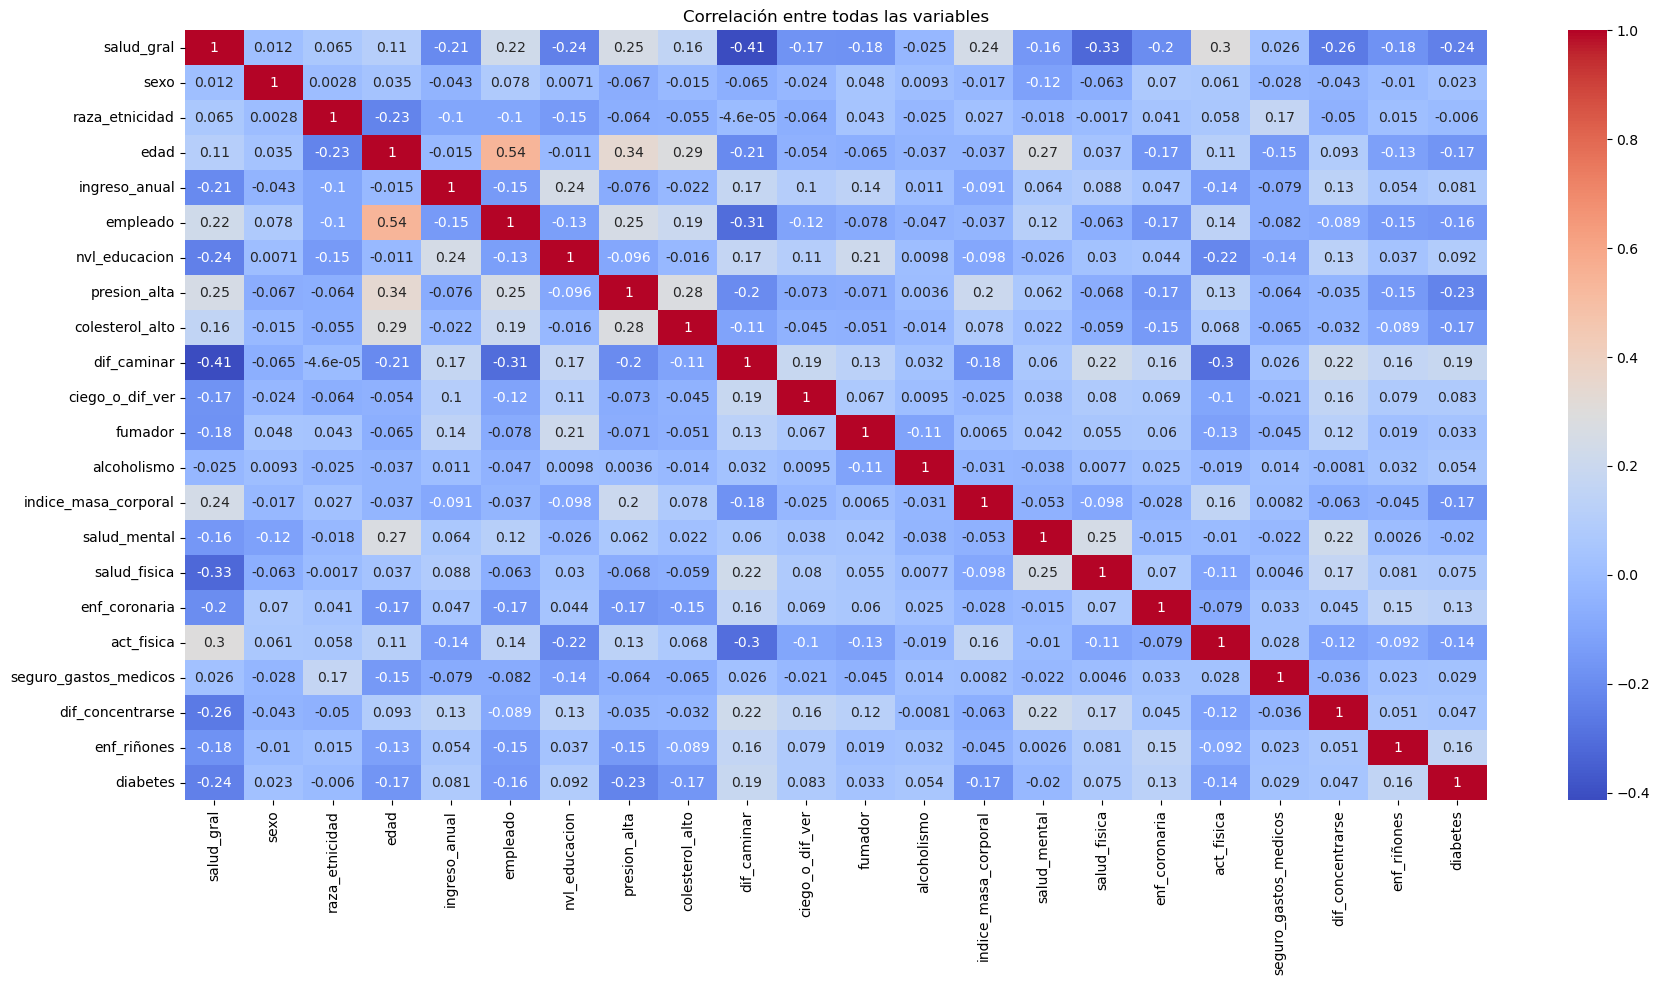

In [7]:
# Separación de las variables numéricas del dataset
numeric = df.select_dtypes(include='number')

# Correlación entre las variables numéricas
corr = numeric.corr()

# Se inicializa una gráfica
plt.figure(figsize=(21, 10))

# Gráficalas tipo heatmap para representar la correlación de las variables numéricas
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlación entre todas las variables') # Se pone nombre a la gráfica
# Se muestra la gráfica
plt.show()

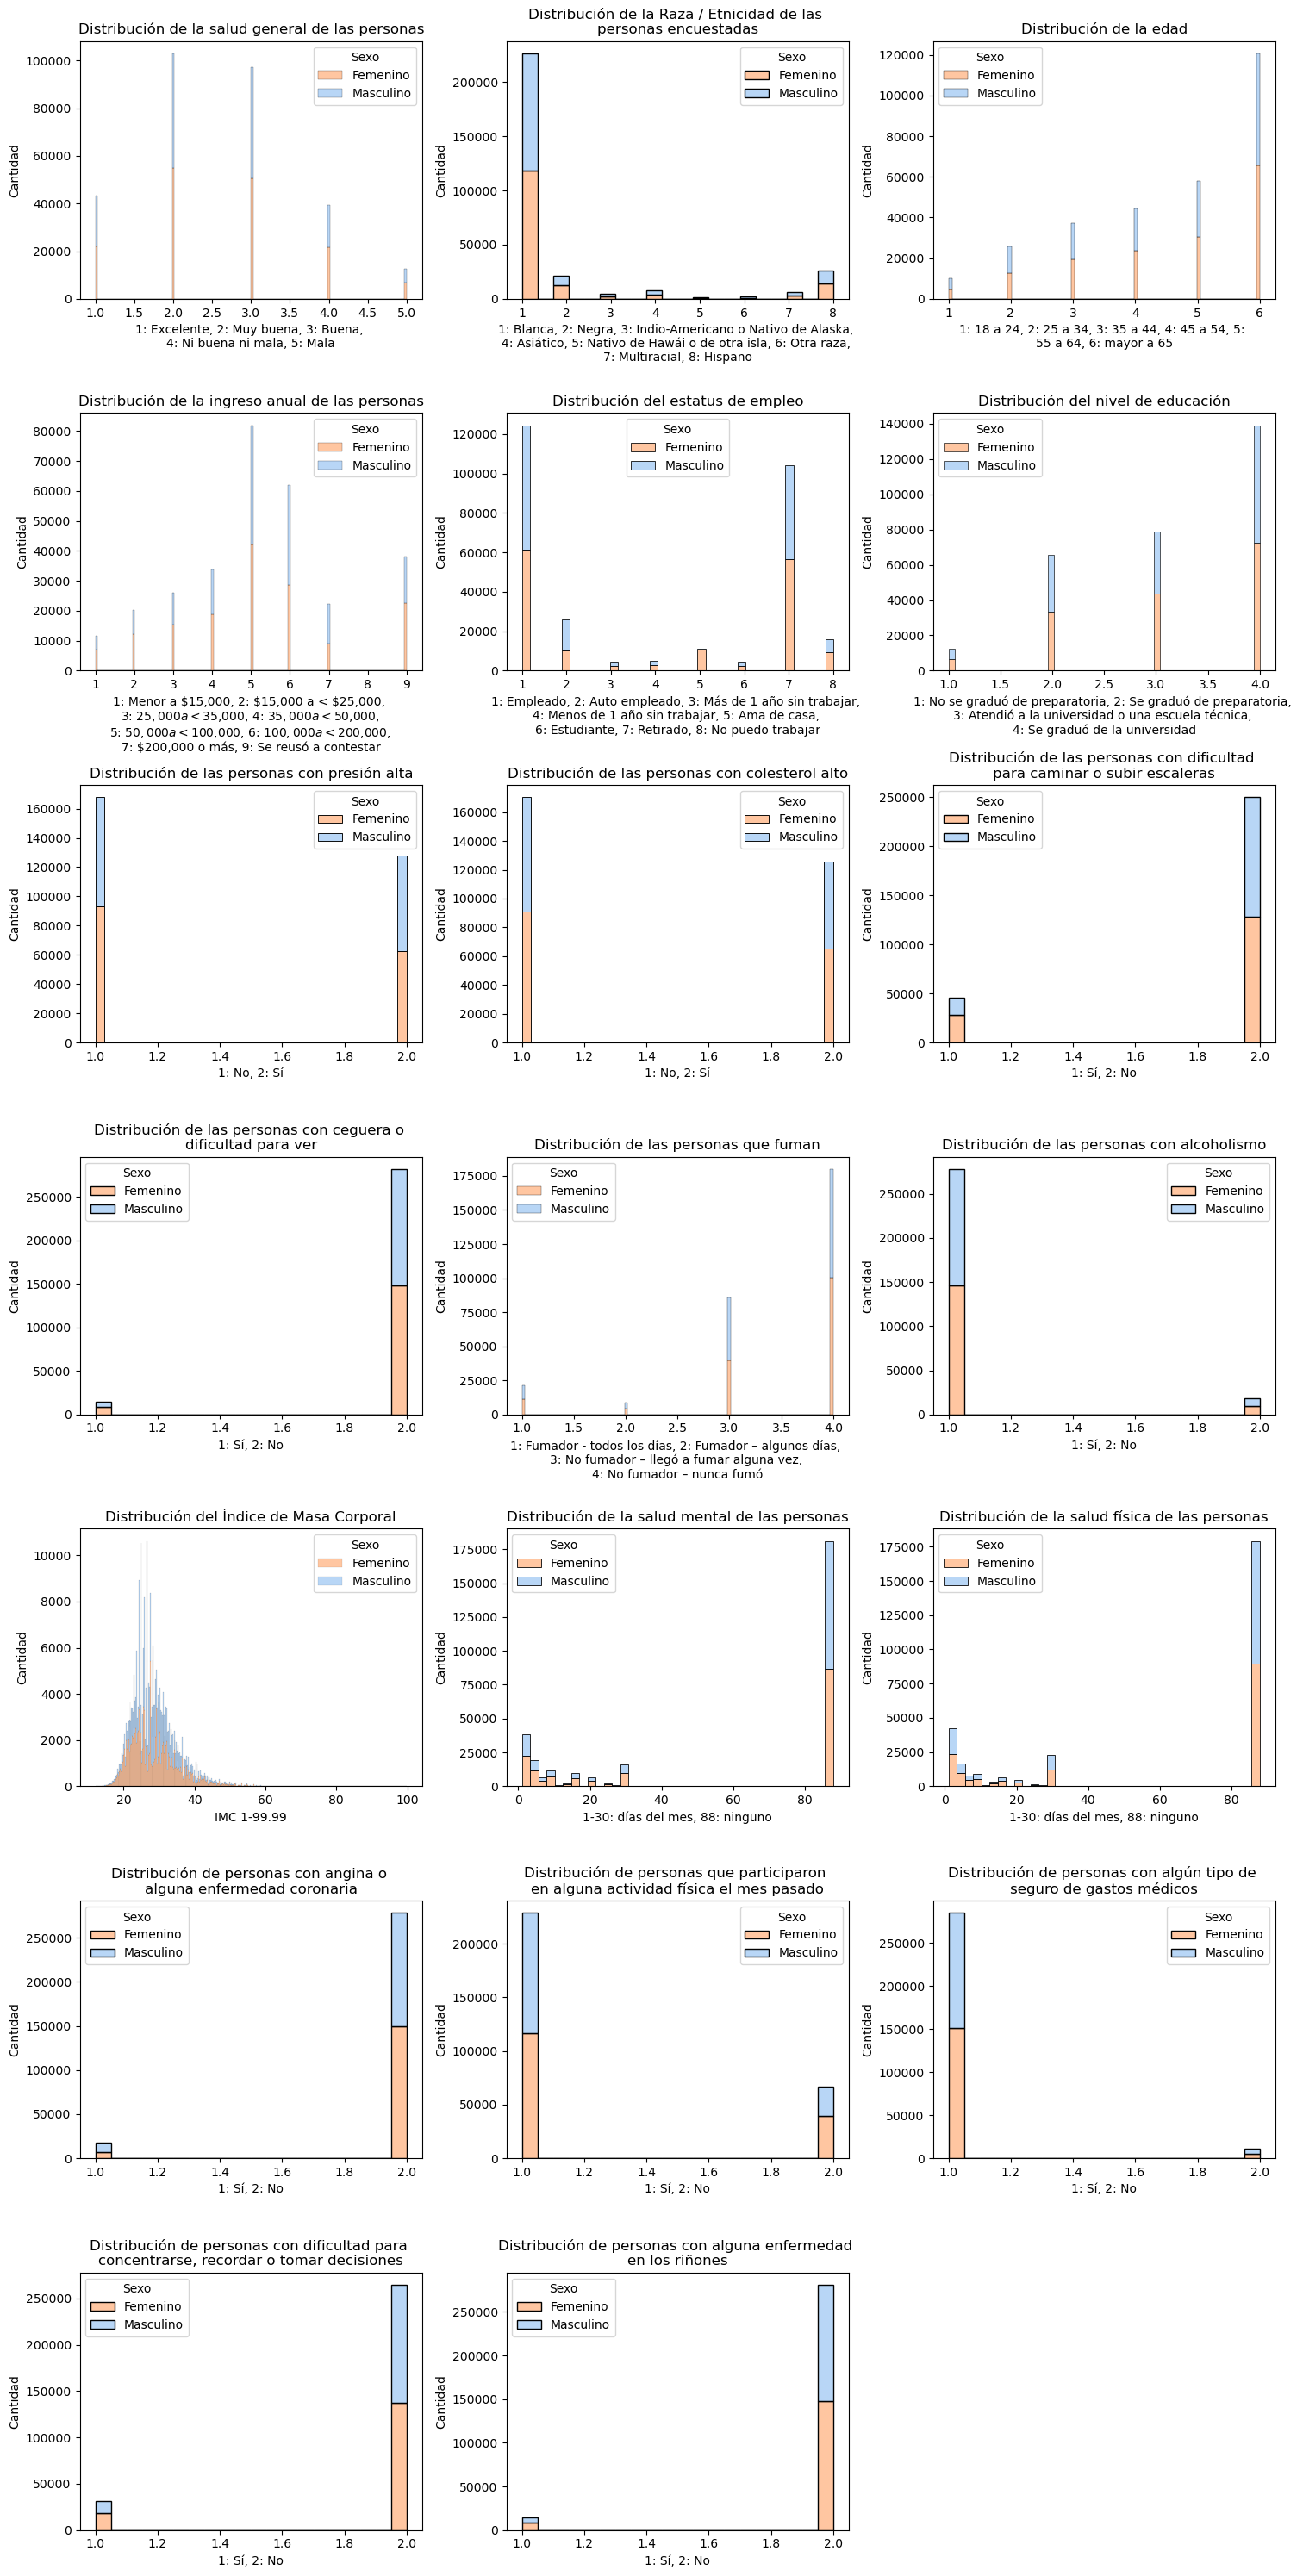

In [88]:
# Se inicializaun array de figuras de 7 filas x 3 columnas
fig, ax = plt.subplots(7, 3, figsize=(15, 30))

sns.histplot(df, x='salud_gral', hue='sexo', multiple='stack', palette='pastel', ax=ax[0][0])
ax[0][0].set_title('Distribución de la salud general de las personas') # Ponemos nombre a la gráfica
ax[0][0].set_xlabel('1: Excelente, 2: Muy buena, 3: Buena, \n4: Ni buena ni mala, 5: Mala') # Ponemos nombre a el eje x de la gráfica
ax[0][0].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[0][0].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='raza_etnicidad', hue='sexo', multiple='stack', palette='pastel', ax=ax[0][1])
ax[0][1].set_title('Distribución de la Raza / Etnicidad de las \npersonas encuestadas') # Ponemos nombre a la gráfica
ax[0][1].set_xlabel('1: Blanca, 2: Negra, 3: Indio-Americano o Nativo de Alaska, \n4: Asiático, 5: Nativo de Hawái o de otra isla, 6: Otra raza, \n7: Multiracial, 8: Hispano') # Ponemos nombre a el eje x de la gráfica
ax[0][1].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[0][1].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='edad', hue='sexo', multiple='stack', palette='pastel', ax=ax[0][2])
ax[0][2].set_title('Distribución de la edad') # Ponemos nombre a la gráfica
ax[0][2].set_xlabel('1: 18 a 24, 2: 25 a 34, 3: 35 a 44, 4: 45 a 54, 5: \n55 a 64, 6: mayor a 65') # Ponemos nombre a el eje x de la gráfica
ax[0][2].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[0][2].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='ingreso_anual', hue='sexo', multiple='stack', palette='pastel', ax=ax[1][0])
ax[1][0].set_title('Distribución de la ingreso anual de las personas') # Ponemos nombre a la gráfica
ax[1][0].set_xlabel('1: Menor a $15,000, 2: $15,000 a < $25,000, \n3: $25,000 a < $35,000, 4: $35,000 a < $50,000, \n5: $50,000 a < $100,000, 6: $100,000 a < $200,000, \n7: $200,000 o más, 9: Se reusó a contestar') # Ponemos nombre a el eje x de la gráfica
ax[1][0].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[1][0].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='empleado', hue='sexo', multiple='stack', palette='pastel', ax=ax[1][1])
ax[1][1].set_title('Distribución del estatus de empleo') # Ponemos nombre a la gráfica
ax[1][1].set_xlabel('1: Empleado, 2: Auto empleado, 3: Más de 1 año sin trabajar, \n4: Menos de 1 año sin trabajar, 5: Ama de casa, \n6: Estudiante, 7: Retirado, 8: No puedo trabajar') # Ponemos nombre a el eje x de la gráfica
ax[1][1].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[1][1].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='nvl_educacion', hue='sexo', multiple='stack', palette='pastel', ax=ax[1][2])
ax[1][2].set_title('Distribución del nivel de educación') # Ponemos nombre a la gráfica
ax[1][2].set_xlabel('1: No se graduó de preparatoria, 2: Se graduó de preparatoria, \n3: Atendió a la universidad o una escuela técnica, \n4: Se graduó de la universidad') # Ponemos nombre a el eje x de la gráfica
ax[1][2].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[1][2].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='presion_alta', hue='sexo', multiple='stack', palette='pastel', ax=ax[2][0])
ax[2][0].set_title('Distribución de las personas con presión alta') # Ponemos nombre a la gráfica
ax[2][0].set_xlabel('1: No, 2: Sí') # Ponemos nombre a el eje x de la gráfica
ax[2][0].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[2][0].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='colesterol_alto', hue='sexo', multiple='stack', palette='pastel', ax=ax[2][1])
ax[2][1].set_title('Distribución de las personas con colesterol alto') # Ponemos nombre a la gráfica
ax[2][1].set_xlabel('1: No, 2: Sí') # Ponemos nombre a el eje x de la gráfica
ax[2][1].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[2][1].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='dif_caminar', hue='sexo', multiple='stack', palette='pastel', ax=ax[2][2])
ax[2][2].set_title('Distribución de las personas con dificultad \npara caminar o subir escaleras') # Ponemos nombre a la gráfica
ax[2][2].set_xlabel('1: Sí, 2: No') # Ponemos nombre a el eje x de la gráfica
ax[2][2].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[2][2].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='ciego_o_dif_ver', hue='sexo', multiple='stack', palette='pastel', ax=ax[3][0])
ax[3][0].set_title('Distribución de las personas con ceguera o \ndificultad para ver') # Ponemos nombre a la gráfica
ax[3][0].set_xlabel('1: Sí, 2: No') # Ponemos nombre a el eje x de la gráfica
ax[3][0].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[3][0].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='fumador', hue='sexo', multiple='stack', palette='pastel', ax=ax[3][1])
ax[3][1].set_title('Distribución de las personas que fuman') # Ponemos nombre a la gráfica
ax[3][1].set_xlabel('1: Fumador - todos los días, 2: Fumador – algunos días, \n3: No fumador – llegó a fumar alguna vez, \n4: No fumador – nunca fumó') # Ponemos nombre a el eje x de la gráfica
ax[3][1].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[3][1].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='alcoholismo', hue='sexo', multiple='stack', palette='pastel', ax=ax[3][2])
ax[3][2].set_title('Distribución de las personas con alcoholismo') # Ponemos nombre a la gráfica
ax[3][2].set_xlabel('1: Sí, 2: No') # Ponemos nombre a el eje x de la gráfica
ax[3][2].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[3][2].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='indice_masa_corporal', hue='sexo', multiple='stack', palette='pastel', ax=ax[4][0])
ax[4][0].set_title('Distribución del Índice de Masa Corporal') # Ponemos nombre a la gráfica
ax[4][0].set_xlabel('IMC 1-99.99') # Ponemos nombre a el eje x de la gráfica
ax[4][0].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[4][0].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='salud_mental', hue='sexo', multiple='stack', palette='pastel', ax=ax[4][1])
ax[4][1].set_title('Distribución de la salud mental de las personas') # Ponemos nombre a la gráfica
ax[4][1].set_xlabel('1-30: días del mes, 88: ninguno') # Ponemos nombre a el eje x de la gráfica
ax[4][1].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[4][1].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='salud_fisica', hue='sexo', multiple='stack', palette='pastel', ax=ax[4][2])
ax[4][2].set_title('Distribución de la salud física de las personas') # Ponemos nombre a la gráfica
ax[4][2].set_xlabel('1-30: días del mes, 88: ninguno') # Ponemos nombre a el eje x de la gráfica
ax[4][2].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[4][2].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='enf_coronaria', hue='sexo', multiple='stack', palette='pastel', ax=ax[5][0])
ax[5][0].set_title('Distribución de personas con angina o \nalguna enfermedad coronaria') # Ponemos nombre a la gráfica
ax[5][0].set_xlabel('1: Sí, 2: No') # Ponemos nombre a el eje x de la gráfica
ax[5][0].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[5][0].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='act_fisica', hue='sexo', multiple='stack', palette='pastel', ax=ax[5][1])
ax[5][1].set_title('Distribución de personas que participaron \nen alguna actividad física el mes pasado') # Ponemos nombre a la gráfica
ax[5][1].set_xlabel('1: Sí, 2: No') # Ponemos nombre a el eje x de la gráfica
ax[5][1].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[5][1].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='seguro_gastos_medicos', hue='sexo', multiple='stack', palette='pastel', ax=ax[5][2])
ax[5][2].set_title('Distribución de personas con algún tipo de \nseguro de gastos médicos') # Ponemos nombre a la gráfica
ax[5][2].set_xlabel('1: Sí, 2: No') # Ponemos nombre a el eje x de la gráfica
ax[5][2].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[5][2].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='dif_concentrarse', hue='sexo', multiple='stack', palette='pastel', ax=ax[6][0])
ax[6][0].set_title('Distribución de personas con dificultad para \nconcentrarse, recordar o tomar decisiones') # Ponemos nombre a la gráfica
ax[6][0].set_xlabel('1: Sí, 2: No') # Ponemos nombre a el eje x de la gráfica
ax[6][0].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[6][0].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

sns.histplot(df, x='enf_riñones', hue='sexo', multiple='stack', palette='pastel', ax=ax[6][1])
ax[6][1].set_title('Distribución de personas con alguna enfermedad \nen los riñones') # Ponemos nombre a la gráfica
ax[6][1].set_xlabel('1: Sí, 2: No') # Ponemos nombre a el eje x de la gráfica
ax[6][1].set_ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
ax[6][1].legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda

# Eliminar los ejes no utilizados
fig.delaxes(ax[6][2])

# Ajustar el layout para que no se sobrepongan las gráficas
plt.tight_layout()

# Se muestran las gráficas
plt.show()

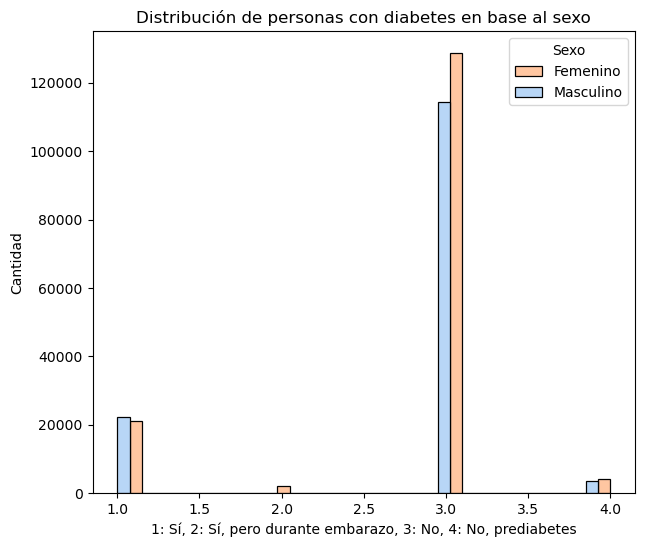

In [111]:
# ANÁLISIS DE LA VARIABLE A PREDECIR 'diabetes'

# Iniciálizamos una figura
plt.figure(figsize=(7, 6))

# Gráfica de barras de la distribución de personas con diabetes en base al sexo
sns.histplot(data=df, x='diabetes', hue='sexo', multiple='dodge', palette='pastel')
plt.title('Distribución de personas con diabetes en base al sexo') # Ponemos nombre a la gráfica
plt.xlabel('1: Sí, 2: Sí, pero durante embarazo, 3: No, 4: No, prediabetes') # Ponemos nombre a el eje x de la gráfica
plt.ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
plt.legend(title='Sexo', labels=['Femenino', 'Masculino']) # Ponemos nombre a la leyenda


# Se muestra la gráfica
plt.show()

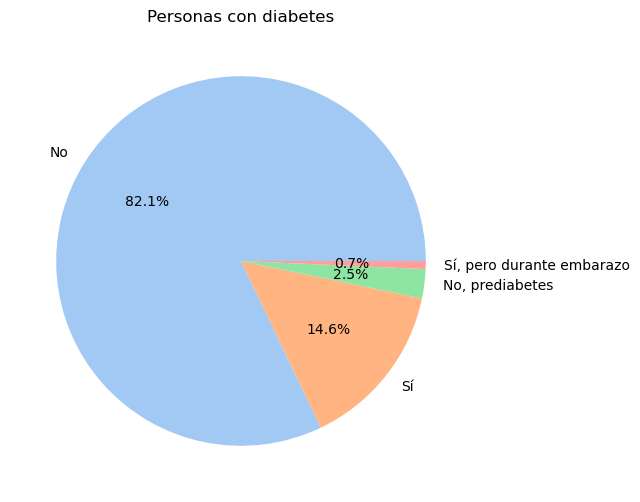

In [109]:
# Iniciálizamos una figura
plt.figure(figsize=(7, 6))

# Conteo de las variables de diabetes
data = df['diabetes'].value_counts()

# Gráfica circular
plt.pie(data, labels=['No', 'Sí', 'No, prediabetes','Sí, pero durante embarazo'], autopct='%1.1f%%', colors=sns.color_palette('pastel', len(data)))
plt.title('Personas con diabetes') # Ponemos nombre a la gráfica

# Se muestra la gráfica
plt.show()

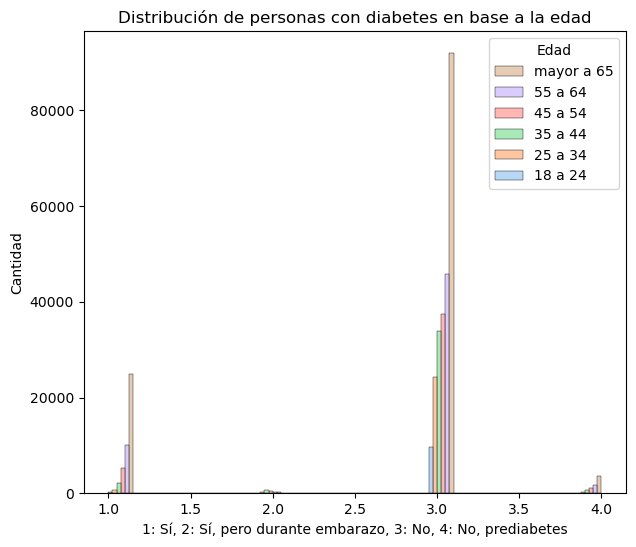

In [118]:
# Iniciálizamos una figura
plt.figure(figsize=(7, 6))

# Gráfica de barras de la distribución de personas con diabetes en base a la edad
sns.histplot(data=df, x='diabetes', hue='edad', multiple='dodge', palette='pastel')
plt.title('Distribución de personas con diabetes en base a la edad') # Ponemos nombre a la gráfica
plt.xlabel('1: Sí, 2: Sí, pero durante embarazo, 3: No, 4: No, prediabetes') # Ponemos nombre a el eje x de la gráfica
plt.ylabel('Cantidad') # Ponemos nombre a el eje y de la gráfica
plt.legend(title='Edad', labels=['mayor a 65', '55 a 64','45 a 54', '35 a 44', '25 a 34', '18 a 24']) # Ponemos nombre a la leyenda


# Se muestra la gráfica
plt.show()

In [128]:
df['diabetes'].value_counts()



3.0    243018
1.0     43348
4.0      7524
2.0      2081
Name: diabetes, dtype: int64

In [74]:
df_filtrado = df.loc[df['indice_masa_corporal'] > 99.00]

In [75]:
df_filtrado

,salud_gral,sexo,raza_etnicidad,edad,ingreso_anual,empleado,nvl_educacion,presion_alta,colesterol_alto,dif_caminar,...,alcoholismo,indice_masa_corporal,salud_mental,salud_fisica,enf_coronaria,act_fisica,seguro_gastos_medicos,dif_concentrarse,enf_riñones,diabetes
45165,5.0,2.0,1.0,5.0,1.0,8.0,3.0,2.0,2.0,1.0,...,1.0,99.79,30.0,30.0,1.0,2.0,2.0,1.0,1.0,1.0
213470,3.0,1.0,1.0,6.0,3.0,7.0,2.0,2.0,1.0,1.0,...,1.0,99.82,88.0,88.0,2.0,2.0,1.0,2.0,2.0,1.0


In [131]:
df.shape

(295971, 22)

In [132]:
df.to_csv('diabetes.csv', index=False)

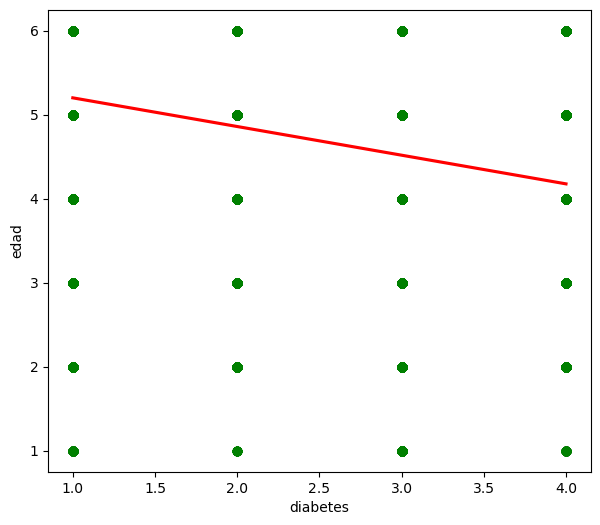

In [136]:
# Iniciálizamos una figura
plt.figure(figsize=(7, 6))

sns.regplot(x=df['diabetes'], y=df['edad'], color="green", line_kws={'color': 'red'})


# Mostrar la gráfica
plt.show()